**Gritap AMR By SSENOGA BADRU**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import seaborn as sns
import geopandas
from libpysal.weights import Queen
import geopandas as gpd

In [9]:
data = pd.read_csv('/content/drive/MyDrive/gritapamrdatasets/azithromycin/Azithromycin_subset_clean.csv')

In [10]:
def subset_and_save_antibiotic_data(data, antibiotic_name):
    # Define the fixed set of columns
    base_columns = [
        'Isolate Id', 'Study', 'Species', 'Family', 'Country', 'State',
        'Gender', 'Age Group', 'Speciality', 'Source', 'In / Out Patient',
        'Year', 'Phenotype', 'AMPC', 'SHV', 'TEM', 'CTXM1', 'CTXM2', 'CTXM825',
        'CTXM9', 'VEB', 'PER', 'GES', 'ACC', 'CMY1MOX', 'CMY11', 'DHA', 'FOX',
        'ACTMIR', 'KPC', 'OXA', 'NDM', 'IMP', 'VIM', 'SPM', 'GIM'
    ]

    # Construct the full list of columns including the antibiotic columns
    antibiotic_columns = [antibiotic_name, f"{antibiotic_name}_I"]
    all_columns = base_columns + antibiotic_columns

    missing_columns = [col for col in all_columns if col not in data.columns]
    if missing_columns:
        print(f"Warning: The following columns were not found in the DataFrame: {missing_columns}")
        # Filter out missing columns to avoid errors, or you could raise an error
        all_columns = [col for col in all_columns if col in data.columns]
        if not all_columns:
             print("Error: No valid columns remaining to subset.")
             return


    # Subset the DataFrame
    subset_data = data[all_columns]

    # Define the output filename
    output_filename = f"{antibiotic_name}_subset.csv"

    # Save the subset data to a CSV file
    subset_data.to_csv(output_filename, index=False)

    print(f"Subset data saved to {output_filename}")

In [11]:
# Azithromycin
subset_and_save_antibiotic_data(data, 'Azithromycin')

Subset data saved to Azithromycin_subset.csv


In [12]:
# Load and preprocess data
amo = pd.read_csv('/content/Azithromycin_subset.csv')

In [13]:
amo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161065 entries, 0 to 161064
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Isolate Id        161065 non-null  int64 
 1   Study             161065 non-null  object
 2   Species           161065 non-null  object
 3   Family            161065 non-null  object
 4   Country           161065 non-null  object
 5   Gender            159298 non-null  object
 6   Age Group         161065 non-null  object
 7   Speciality        161065 non-null  object
 8   Source            161065 non-null  object
 9   In / Out Patient  110684 non-null  object
 10  Year              161065 non-null  int64 
 11  Phenotype         47510 non-null   object
 12  Azithromycin      4500 non-null    object
 13  Azithromycin_I    4377 non-null    object
dtypes: int64(2), object(12)
memory usage: 17.2+ MB


In [14]:
# Define a function for cleaning and saving
def clean_and_save_data(data, antibiotic):
    # Columns of interest
    columns_of_interest = columns_of_interest = ['Isolate Id', 'Study', 'Species', 'Family', 'Country',
       'Gender', 'Age Group', 'Speciality', 'Source', 'In / Out Patient',
       'Year', 'Phenotype', antibiotic, f'{antibiotic}_I']
    data = data[columns_of_interest].copy()
    data = data.sample(frac=0.8, random_state=42)
    data.to_csv(f'{antibiotic}_subset_clean.csv', index=False)
    print(f"Data cleaned and saved!")

clean_and_save_data(amo, 'Azithromycin')

Data cleaned and saved!


In [15]:
amo['Azithromycin'].unique()

array([nan, '0.12', '0.06', '2', '64', '1', '0.5', '4', '<=0.03', '>64',
       '8', '16', '>256', '<=0.12', '32', '0.25', '>8', '128', '0.03'],
      dtype=object)

In [16]:
country_to_continent = {
    'France': 'Europe',
    'Spain': 'Europe',
    'Belgium': 'Europe',
    'Italy': 'Europe',
    'Germany': 'Europe',
    'Canada': 'North America',
    'Ireland': 'Europe',
    'Portugal': 'Europe',
    'Israel': 'Asia',
    'Greece': 'Europe',
    'China': 'Asia',
    'United Kingdom': 'Europe',
    'Kuwait': 'Asia',
    'Poland': 'Europe',
    'Switzerland': 'Europe',
    'Hungary': 'Europe',
    'Austria': 'Europe',
    'Colombia': 'South America',
    'Chile': 'South America',
    'Finland': 'Europe',
    'Australia': 'Oceania',
    'Mexico': 'North America',
    'Denmark': 'Europe',
    'Sweden': 'Europe',
    'Hong Kong': 'Asia',
    'Japan': 'Asia',
    'Croatia': 'Europe',
    'Malaysia': 'Asia',
    'Nigeria': 'Africa',
    'Kenya': 'Africa',
    'Czech Republic': 'Europe',
    'Netherlands': 'Europe',
    'Russia': 'Europe',
    'Romania': 'Europe',
    'Venezuela': 'South America',
    'Thailand': 'Asia',
    'Philippines': 'Asia',
    'Turkey': 'Asia',
    'Korea, South': 'Asia',
    'South Africa': 'Africa',
    'Argentina': 'South America',
    'Taiwan': 'Asia',
    'Brazil': 'South America',
    'Panama': 'North America',
    'Jordan': 'Asia',
    'Saudi Arabia': 'Asia',
    'Pakistan': 'Asia',
    'Guatemala': 'North America',
    'Morocco': 'Africa',
    'India': 'Asia',
    'Singapore': 'Asia',
    'Vietnam': 'Asia',
    'Latvia': 'Europe',
    'Lithuania': 'Europe',
    'Serbia': 'Europe',
    'Dominican Republic': 'North America',
    'Costa Rica': 'North America',
    'Ukraine': 'Europe',
    'Ivory Coast': 'Africa',
    'Lebanon': 'Asia',
    'New Zealand': 'Oceania',
    'Qatar': 'Asia',
    'Slovenia': 'Europe',
    'Cameroon': 'Africa',
    'Jamaica': 'North America',
    'Bulgaria': 'Europe',
    'Norway': 'Europe',
    'Honduras': 'North America',
    'Puerto Rico': 'North America',
    'Nicaragua': 'North America',
    'Slovak Republic': 'Europe',
    'Oman': 'Asia',
    'Malawi': 'Africa',
    'Ghana': 'Africa',
    'Uganda': 'Africa',
    'Namibia': 'Africa',
    'Indonesia': 'Asia',
    'Mauritius': 'Africa',
    'Estonia': 'Europe',
    'El Salvador': 'North America',
    'Tunisia': 'Africa',
    'Egypt': 'Africa'
}

In [17]:
amo['Continent'] = amo['Country'].map(country_to_continent)

# Statistical Analysis

In [18]:
df = amo.copy()

In [19]:
# Focus on Azithromycin resistance
df['resistant'] = (df['Azithromycin_I'] == 'Resistant').astype(int)
df['total'] = 1  # Each row is one isolate

In [20]:
# Aggregate by Country, Year, and optionally Species
agg_df = df.groupby(['Country', 'Year', 'Species']).agg({
    'resistant': 'sum',
    'total': 'count'
}).reset_index()

In [21]:
agg_df['Continent'] = agg_df['Country'].map(country_to_continent)

In [22]:
# Create index mappings for modeling
continents = agg_df['Continent'].unique()
continent_idx = {cont: i for i, cont in enumerate(continents)}
agg_df['continent_idx'] = agg_df['Continent'].map(continent_idx)

countries = agg_df['Country'].unique()
country_idx = {country: i for i, country in enumerate(countries)}
agg_df['country_idx'] = agg_df['Country'].map(country_idx)

In [23]:
# Handle missing data
agg_df = agg_df.dropna(subset=['Country', 'Year', 'resistant', 'total'])

In [24]:
# Centre the year
mean_year = agg_df['Year'].mean()
agg_df['year_centered'] = agg_df['Year'] - mean_year

In [25]:
# Prepare data
n_continents = len(continents)
n_countries = len(countries)
country_to_continent = np.array([continent_idx[agg_df[agg_df['Country'] == country]['Continent'].iloc[0]] for country in countries])

In [27]:
with pm.Model() as model:
    # Global hyperparameters
    mu_alpha_global = pm.Normal('mu_alpha_global', mu=0, sigma=1)
    sigma_alpha_global = pm.HalfNormal('sigma_alpha_global', sigma=1)
    mu_beta_global = pm.Normal('mu_beta_global', mu=0, sigma=1)
    sigma_beta_global = pm.HalfNormal('sigma_beta_global', sigma=1)

    # Continent-level parameters
    alpha_continent = pm.Normal('alpha_continent', mu=mu_alpha_global, sigma=sigma_alpha_global, shape=n_continents)
    beta_continent = pm.Normal('beta_continent', mu=mu_beta_global, sigma=sigma_beta_global, shape=n_continents)

    # Country-level parameters
    sigma_alpha_country = pm.HalfNormal('sigma_alpha_country', sigma=1)
    sigma_beta_country = pm.HalfNormal('sigma_beta_country', sigma=1)
    alpha_country = pm.Normal('alpha_country', mu=alpha_continent[country_to_continent], sigma=sigma_alpha_country, shape=n_countries)
    beta_country = pm.Normal('beta_country', mu=beta_continent[country_to_continent], sigma=sigma_beta_country, shape=n_countries)

    # Linear predictor
    linear_predictor = alpha_country[agg_df['country_idx']] + beta_country[agg_df['country_idx']] * agg_df['year_centered']

    # Resistance rate
    p = pm.math.sigmoid(linear_predictor)

    # Likelihood
    resistant_obs = pm.Binomial('resistant_obs', n=agg_df['total'], p=p, observed=agg_df['resistant'])

    # Sample from posterior
    trace = pm.sample(1000, tune=1000, chains=4, cores=4, return_inferencedata=True)

Output()

ERROR:pymc.stats.convergence:There were 1176 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


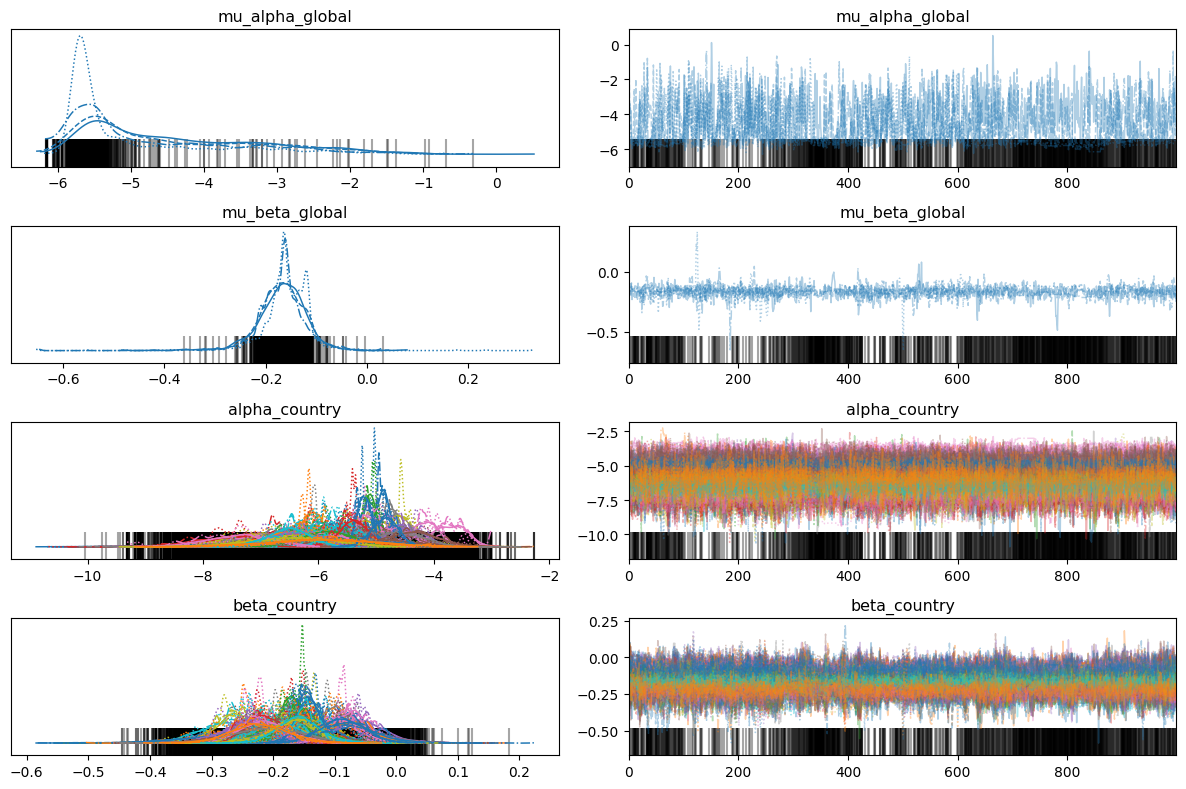

In [28]:
# Sampling and Convergence
az.plot_trace(trace, var_names=['mu_alpha_global', 'mu_beta_global', 'alpha_country', 'beta_country'])
plt.tight_layout()
plt.savefig('Azithromycin_sampling_result.png')

In [29]:
# Get the summary DataFrame
summary_df = az.summary(trace, var_names=['alpha_country', 'beta_country'], hdi_prob=0.95)

# Create a mapping from index to country name
# We need the inverse of the country_idx dictionary
idx_to_country = {v: k for k, v in country_idx.items()}

# Extract the numerical index from the summary DataFrame index and map to country name
summary_df['Country'] = summary_df.index.map(lambda x: idx_to_country[int(x.split('[')[1].split(']')[0])])

# Reorder columns to put Country at the beginning
summary_df = summary_df[['Country'] + [col for col in summary_df.columns if col != 'Country']]

# Display the modified summary DataFrame
display(summary_df)

,Country,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_country[0],Argentina,-5.402,0.249,-5.900,-4.960,0.022,0.006,142.0,698.0,1.03
alpha_country[1],Australia,-7.036,0.587,-8.282,-6.096,0.060,0.016,81.0,452.0,1.05
alpha_country[2],Austria,-6.235,0.447,-7.173,-5.458,0.047,0.010,90.0,2086.0,1.03
alpha_country[3],Belgium,-5.474,0.185,-5.832,-5.113,0.011,0.005,325.0,651.0,1.02
alpha_country[4],Brazil,-5.841,0.347,-6.491,-5.105,0.027,0.021,169.0,60.0,1.02
...,...,...,...,...,...,...,...,...,...,...
beta_country[77],Uganda,-0.205,0.057,-0.315,-0.091,0.003,0.003,441.0,577.0,1.06
beta_country[78],Ukraine,-0.169,0.042,-0.260,-0.090,0.003,0.002,277.0,208.0,1.00
beta_country[79],United Kingdom,-0.152,0.036,-0.235,-0.090,0.005,0.002,42.0,203.0,1.07
beta_country[80],Venezuela,-0.092,0.038,-0.166,-0.018,0.005,0.002,49.0,107.0,1.07


### 1. Trends and Patterns over time

In [30]:
beta_summary = az.summary(trace, var_names=['beta_country'], hdi_prob=0.95)
beta_summary.index = countries  # Map indices to country names
beta_summary

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Argentina,-0.089,0.033,-0.151,-0.030,0.007,0.002,23.0,71.0,1.12
Australia,-0.246,0.067,-0.392,-0.131,0.004,0.002,263.0,335.0,1.02
Austria,-0.168,0.039,-0.258,-0.098,0.003,0.001,117.0,676.0,1.03
Belgium,-0.161,0.026,-0.213,-0.113,0.001,0.001,326.0,658.0,1.04
Brazil,-0.078,0.039,-0.151,0.004,0.002,0.002,409.0,684.0,1.03
...,...,...,...,...,...,...,...,...,...
Uganda,-0.205,0.057,-0.315,-0.091,0.003,0.003,441.0,577.0,1.06
Ukraine,-0.169,0.042,-0.260,-0.090,0.003,0.002,277.0,208.0,1.00
United Kingdom,-0.152,0.036,-0.235,-0.090,0.005,0.002,42.0,203.0,1.07
Venezuela,-0.092,0.038,-0.166,-0.018,0.005,0.002,49.0,107.0,1.07


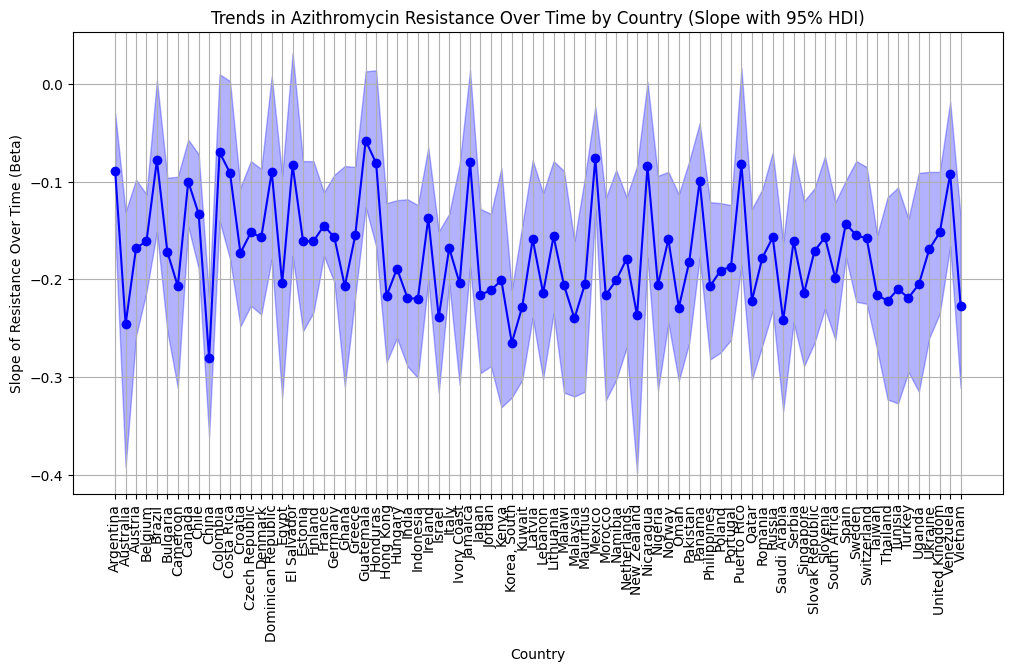

In [31]:
# Visualize trends
plt.figure(figsize=(12, 6))
plt.plot(beta_summary['mean'], marker='o', linestyle='-', color='b')
plt.fill_between(beta_summary.index,
                 beta_summary['hdi_2.5%'],
                 beta_summary['hdi_97.5%'],
                 color='b', alpha=0.3)

plt.xlabel('Country')
plt.ylabel('Slope of Resistance Over Time (Beta)')
plt.title('Trends in Azithromycin Resistance Over Time by Country (Slope with 95% HDI)')
plt.xticks(rotation=90)
plt.grid(True)
plt.savefig('Azithromycin_trend_pattern.png')
plt.show()

### 2. Comparing Regional and Country-Specific Differences

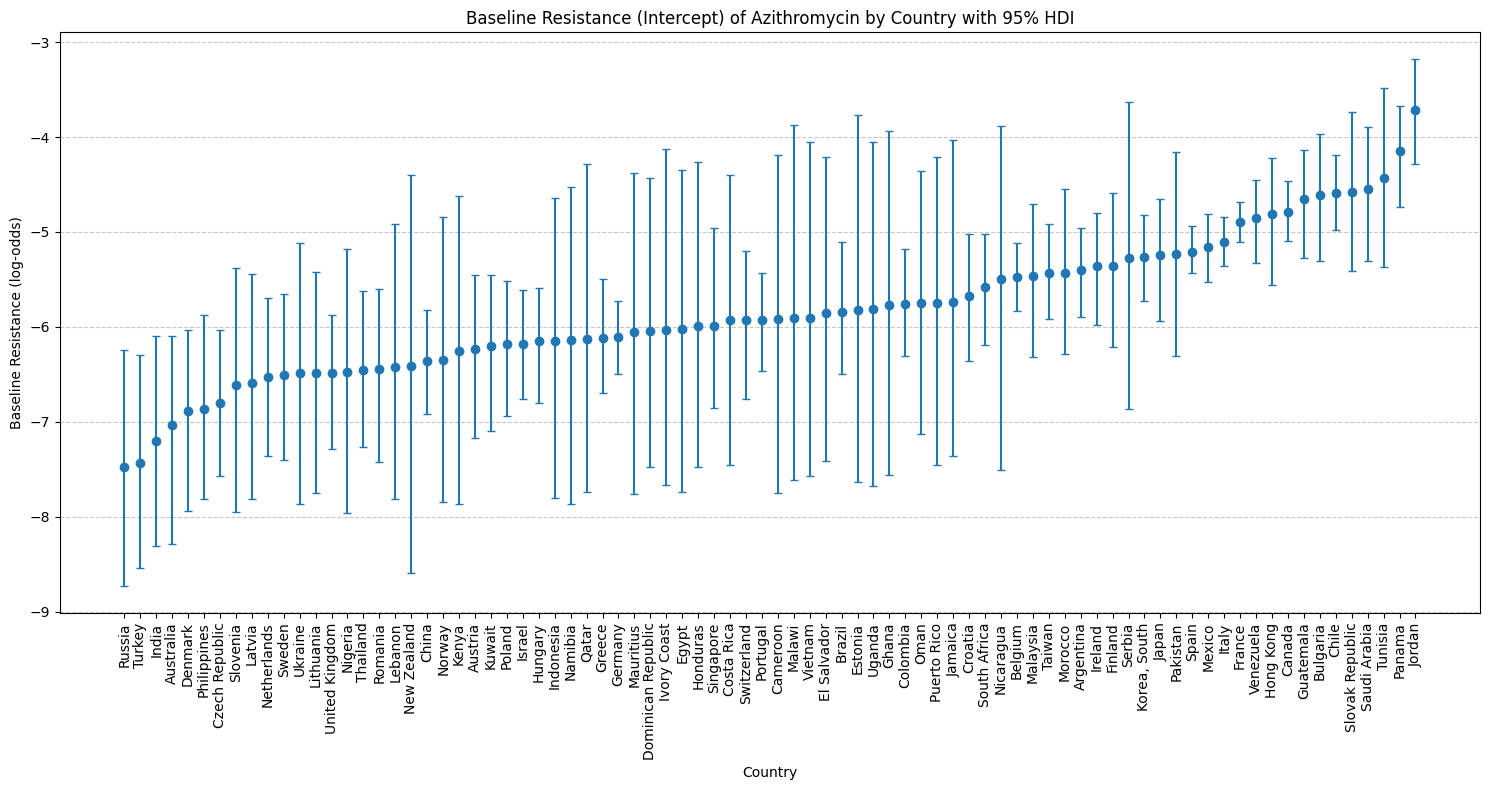

In [34]:
# Compare baseline resistance alpha and beta trends across countries
alpha_summary = az.summary(trace, var_names=['alpha_country'], hdi_prob=0.95)
alpha_summary.index = countries

# Calculate the lower and upper bounds for the error bars
alpha_summary['lower_hdi'] = alpha_summary['mean'] - alpha_summary['hdi_2.5%']
alpha_summary['upper_hdi'] = alpha_summary['hdi_97.5%'] - alpha_summary['mean']

# Sort the data by the mean value for better visualization
alpha_summary_sorted = alpha_summary.sort_values(by='mean')

# Create a bar plot with error bars
plt.figure(figsize=(15, 8)) # Adjust figure size as needed
plt.errorbar(alpha_summary_sorted.index, alpha_summary_sorted['mean'],
             yerr=[alpha_summary_sorted['lower_hdi'], alpha_summary_sorted['upper_hdi']],
             fmt='o', capsize=3, linestyle='None')

plt.xlabel('Country')
plt.ylabel('Baseline Resistance (log-odds)')
plt.title('Baseline Resistance (Intercept) of Azithromycin by Country with 95% HDI')
plt.xticks(rotation=90) # Rotate x-axis labels for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.savefig('Azithromycin_baseline_resistance_alpha.png')
plt.show()

#### 4. Detect MIC “creep” in the non-resistant population over time

In [ ]:
#df = amo.copy()

In [41]:
df.columns

Index(['Isolate Id', 'Study', 'Species', 'Family', 'Country', 'Gender',
       'Age Group', 'Speciality', 'Source', 'In / Out Patient', 'Year',
       'Phenotype', 'Azithromycin', 'Azithromycin_I', 'Continent', 'resistant',
       'total'],
      dtype='object')

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161065 entries, 0 to 161064
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Isolate Id        161065 non-null  int64 
 1   Study             161065 non-null  object
 2   Species           161065 non-null  object
 3   Family            161065 non-null  object
 4   Country           161065 non-null  object
 5   Gender            159298 non-null  object
 6   Age Group         161065 non-null  object
 7   Speciality        161065 non-null  object
 8   Source            161065 non-null  object
 9   In / Out Patient  110684 non-null  object
 10  Year              161065 non-null  int64 
 11  Phenotype         47510 non-null   object
 12  Azithromycin      4500 non-null    object
 13  Azithromycin_I    4377 non-null    object
 14  Continent         161065 non-null  object
 15  resistant         161065 non-null  int64 
 16  total             161065 non-null  int

In [43]:
# Prepare data
df = df.dropna(subset = ['Country', 'Year', 'Azithromycin', 'Azithromycin_I']) # no associated gene available

#df['Country'] = df['Country'].fillna(df['Country'].mode()[0])
#df['Year'] = df['Year'].fillna(df['Year'].mode()[0])
#df['Azithromycin'] = df['Azithromycin'].fillna(df['Azithromycin'].mode()[0])
#df['Azithromycin_I'] = df['Azithromycin_I'].fillna(df['Azithromycin_I'].mode()[0])
#df['NDM'] = df['NDM'].fillna(df['NDM'].mode()[0])
#df['CTXM1'] = df['CTXM1'].fillna(df['CTXM1'].mode()[0])
#df['OXA'] = df['OXA'].fillna(df['OXA'].mode()[0])

# Sample data
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4377 entries, 57 to 161034
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Isolate Id        4377 non-null   int64 
 1   Study             4377 non-null   object
 2   Species           4377 non-null   object
 3   Family            4377 non-null   object
 4   Country           4377 non-null   object
 5   Gender            4318 non-null   object
 6   Age Group         4377 non-null   object
 7   Speciality        4377 non-null   object
 8   Source            4377 non-null   object
 9   In / Out Patient  3483 non-null   object
 10  Year              4377 non-null   int64 
 11  Phenotype         718 non-null    object
 12  Azithromycin      4377 non-null   object
 13  Azithromycin_I    4377 non-null   object
 14  Continent         4377 non-null   object
 15  resistant         4377 non-null   int64 
 16  total             4377 non-null   int64 
dtypes: int64(4), obj

In [44]:
# Create indices for Continent and Country for hierarchical modeling
continents = df['Continent'].unique()
continent_idx = {cont: i for i, cont in enumerate(continents)}

countries = df['Country'].unique()
country_idx = {country: i for i, country in enumerate(countries)}

df = df.copy()

df['continent_idx'] = df['Continent'].map(continent_idx)
df['country_idx'] = df['Country'].map(country_idx)

In [45]:
# Center the Year variable to improve model stability
df['year_centered'] = df['Year'] - df['Year'].mean()

In [46]:
df['Azithromycin'].unique()

array(['0.12', '0.06', '2', '64', '1', '0.5', '4', '<=0.03', '>64', '8',
       '16', '<=0.12', '32', '>256', '0.25', '>8', '128', '0.03'],
      dtype=object)

In [47]:
# Convert MIC values
def convert_mic_to_numeric(mic_value):
    if isinstance(mic_value, (int, float)):
        return float(mic_value)
    if isinstance(mic_value, str):
        mic_value = mic_value.replace('<=', '').replace('>=', '').replace('<', '').replace('>', '').strip()
        if not mic_value:
            return np.nan
        try:
            return float(mic_value)
        except ValueError:
            return np.nan
    return np.nan

df['Azithromycin_numeric'] = df['Azithromycin'].apply(convert_mic_to_numeric)

In [48]:
# Filter non-resistant isolates
non_resistant = df[df['Azithromycin_I'].isin(['Susceptible', 'Intermediate'])].copy()

# Calculate log2 of the numeric Amikacin values
non_resistant.dropna(subset=['Azithromycin_numeric'], inplace=True)
non_resistant['log2_mic'] = np.log2(non_resistant['Azithromycin_numeric'])

In [49]:
# Assume lower detection limit (e.g., MIC <= 0.25 is censored)
lower_limit = np.log2(0.25)
non_resistant['censored'] = non_resistant['log2_mic'] <= lower_limit

In [50]:
n_continents = len(continents)
n_countries = len(countries)
# Create a mapping from all countries to their continents using the original dictionary
# Filter this mapping to include only countries present in the non_resistant dataframe
countries_in_non_resistant = non_resistant['Country'].unique()
continent_idx_for_non_resistant_countries = np.array([continent_idx[country_to_continent[c]] for c in countries if c in countries_in_non_resistant])

# Update countries and n_countries to reflect only those in the non_resistant dataframe
countries = countries_in_non_resistant
n_countries = len(countries)
country_idx = {country: i for i, country in enumerate(countries)}
non_resistant = non_resistant.copy() # Avoid SettingWithCopyWarning
non_resistant['country_idx'] = non_resistant['Country'].map(country_idx)

country_to_continent_for_model = continent_idx_for_non_resistant_countries

In [51]:
import pytensor.tensor as pt

with pm.Model() as mic_model:
    # Global hyperparameters
    mu_alpha_global = pm.Normal('mu_alpha_global', mu=0, sigma=1)
    sigma_alpha_global = pm.HalfNormal('sigma_alpha_global', sigma=1)
    mu_beta_global = pm.Normal('mu_beta_global', mu=0, sigma=1)
    sigma_beta_global = pm.HalfNormal('sigma_beta_global', sigma=1)

    # Continent-level parameters
    alpha_continent = pm.Normal('alpha_continent', mu=mu_alpha_global, sigma=sigma_alpha_global, shape=n_continents)
    beta_continent = pm.Normal('beta_continent', mu=mu_beta_global, sigma=sigma_beta_global, shape=n_continents)

    # Create intermediate tensors for continent-level means per country
    # Convert the NumPy array to a PyTensor tensor variable
    country_to_continent_tensor = pt.as_tensor_variable(country_to_continent_for_model, dtype='int64')

    alpha_continent_for_countries = alpha_continent[country_to_continent_tensor]
    beta_continent_for_countries = beta_continent[country_to_continent_tensor]

    # Country-level parameters
    sigma_alpha_country = pm.HalfNormal('sigma_alpha_country', sigma=1)
    sigma_beta_country = pm.HalfNormal('sigma_beta_country', sigma=1)
    # Use intermediate tensors as mu parameters
    alpha_country = pm.Normal('alpha_country', mu=alpha_continent_for_countries, sigma=sigma_alpha_country, shape=n_countries)
    beta_country = pm.Normal('beta_country', mu=beta_continent_for_countries, sigma=sigma_beta_country, shape=n_countries)

    # Linear predictor
    mu = alpha_country[non_resistant['country_idx'].values] + beta_country[non_resistant['country_idx'].values] * non_resistant['year_centered'].values
    sigma = pm.HalfNormal('sigma', sigma=1)

    # Define likelihood using pm.Potential for left-censoring
    # For uncensored observations (log2_mic > lower_limit), add the log-pdf
    logp_observed = pm.logp(pm.Normal.dist(mu=mu, sigma=sigma), non_resistant['log2_mic'].values)

    # For censored observations (log2_mic <= lower_limit), add the log-cdf evaluated at the lower limit
    logp_censored = pm.logcdf(pm.Normal.dist(mu=mu, sigma=sigma), lower_limit)

    # Combine log-likelihoods based on the 'censored' flag
    # Use pt.where to select the appropriate log-likelihood for each observation
    total_logp = pt.where(non_resistant['censored'].values, logp_censored, logp_observed)

    # Add the total log-likelihood to the model using pm.Potential
    pm.Potential('observed_likelihood', total_logp)

    # Sample from posterior
    trace_mic = pm.sample(1000, tune=1000, chains=4, cores=4, return_inferencedata=True)

Output()

ERROR:pymc.stats.convergence:There were 1012 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


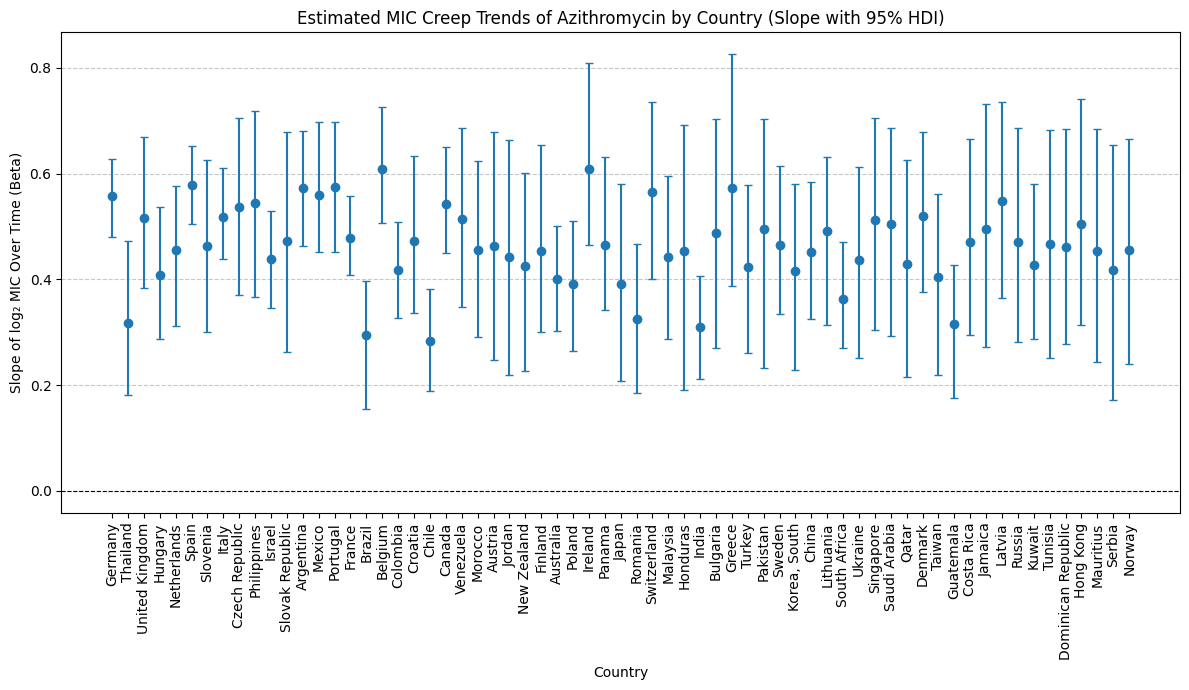

In [52]:
# Visualize MIC Creep (Slope of log₂ MIC) in Non-Resistant Population with countries on the x-axis
beta_summary = az.summary(trace_mic, var_names=['beta_country'], hdi_prob=0.95)
beta_summary.index = countries # Map indices to country names

plt.figure(figsize=(12, 7)) # Adjusted figure size for better readability
plt.errorbar(x=beta_summary.index, y=beta_summary['mean'],
             yerr=[beta_summary['mean'] - beta_summary['hdi_2.5%'], beta_summary['hdi_97.5%'] - beta_summary['mean']],
             fmt='o', capsize=3, linestyle='') # Use fmt='o' and linestyle='' for just points and error bars

plt.axhline(0, color='black', linestyle='--', linewidth=0.8) # Add a horizontal line at 0 for reference

plt.xlabel('Country')
plt.ylabel('Slope of log₂ MIC Over Time (Beta)')
plt.title('Estimated MIC Creep Trends of Azithromycin by Country (Slope with 95% HDI)')
plt.xticks(rotation=90) # Rotate country names for readability
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.savefig('Azithromycin_mic_creep_trend.png')
plt.show()